# Sistem Visi Komputer untuk Klasifikasi Penyakit Daun Cabai
## Analisis Komparasi: EfficientNet-B0, DenseNet-121, ResNet-50
---

### 1. Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'Torchvision: {torchvision.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128


### 2. Configuration

In [5]:
# ============================================================
# UBAH PATH INI SESUAI LOKASI DATASET DI GOOGLE DRIVE
DATA_DIR = '/content/drive/MyDrive/chilli_data'
# ============================================================

CLASSES = ['cercospora', 'healthy', 'mites_and_thrips', 'powdery_mildew']
NUM_CLASSES = len(CLASSES)
IMG_SIZE = 224       # ResNet/DenseNet/EfficientNet standard
BATCH_SIZE = 32
NUM_EPOCHS = 25
LR = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 7

# ImageNet normalization
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

### 3. Data Loading & Validation

Distribusi kelas:
  cercospora: 902
  healthy: 338
  mites_and_thrips: 305
  powdery_mildew: 166
Total: 1711


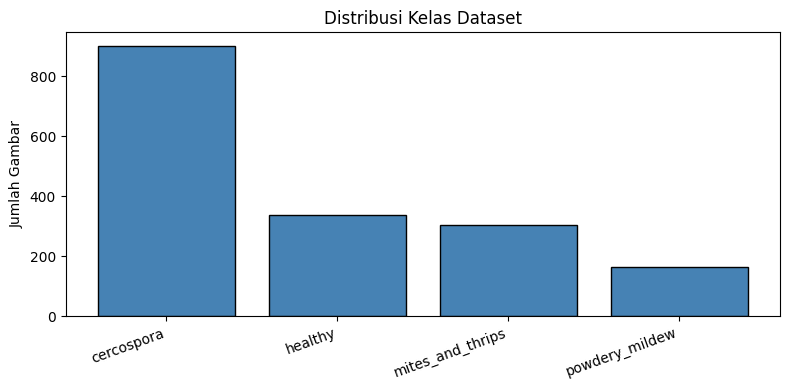

In [6]:
# Validate folder structure & count per class
class_counts = {}
all_paths, all_labels = [], []

for idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(DATA_DIR, cls)
    assert os.path.exists(cls_dir), f'Folder tidak ditemukan: {cls_dir}'
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(files)
    for f in files:
        all_paths.append(os.path.join(cls_dir, f))
        all_labels.append(idx)

print('Distribusi kelas:')
for cls, cnt in class_counts.items():
    print(f'  {cls}: {cnt}')
print(f'Total: {len(all_paths)}')

# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
ax.set_title('Distribusi Kelas Dataset')
ax.set_ylabel('Jumlah Gambar')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 4. Stratified Split (70/15/15)

In [7]:
# Stratified train/temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=SEED
)

# Stratified val/test split from temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')

Train : 1197
Val   : 257
Test  : 257


### 5. Custom Dataset & Transforms

In [8]:
from torch.utils.data import Dataset

class ChilliDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# Color-safe augmentation (sesuai policy AGENTS.md)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),  # max ±5%
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = ChilliDataset(X_train, y_train, transform=train_transform)
val_dataset   = ChilliDataset(X_val,   y_val,   transform=val_test_transform)
test_dataset  = ChilliDataset(X_test,  y_test,  transform=val_test_transform)

### 6. Imbalance Handling — WeightedRandomSampler + Class Weights

In [9]:
# Class weights for loss function
train_counts = Counter(y_train)
total_train  = len(y_train)
class_weights = torch.tensor(
    [total_train / (NUM_CLASSES * train_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(DEVICE)
print('Class weights:', class_weights.cpu().numpy())

# WeightedRandomSampler
sample_weights = [class_weights[y_train[i]].item() for i in range(len(y_train))]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Class weights: [0.47424722 1.2626582  1.4049295  2.5797415 ]
Train batches: 38 | Val: 9 | Test: 9


### 7. Model Definitions

In [10]:
def get_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

def get_densenet121(num_classes):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

def get_efficientnet_b0(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

MODEL_REGISTRY = {
    'ResNet-50'       : get_resnet50,
    'DenseNet-121'    : get_densenet121,
    'EfficientNet-B0' : get_efficientnet_b0,
}

### 8. Training & Validation Loop

In [11]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def train_model(name, model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, patience):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = None
    no_improve   = 0

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(vl_loss)
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        print(f'[{name}] Epoch {epoch:02d}/{num_epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
              f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | '
              f'Time: {elapsed:.1f}s')

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    model.load_state_dict(best_weights)
    return model, history

### 9. Comparative Training — All Three Models

In [12]:
results   = {}   # stores test metrics per model
histories = {}   # stores training history per model

for model_name, model_fn in MODEL_REGISTRY.items():
    print(f'\n{'='*60}')
    print(f'  Training: {model_name}')
    print(f'{'='*60}')

    model = model_fn(NUM_CLASSES).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    model, history = train_model(
        model_name, model,
        train_loader, val_loader,
        criterion, optimizer, scheduler,
        NUM_EPOCHS, EARLY_STOP_PATIENCE
    )

    # Evaluate on test set
    _, test_acc, preds, labels_true = evaluate(model, test_loader, criterion)
    report = classification_report(labels_true, preds, target_names=CLASSES, output_dict=True)

    histories[model_name] = history
    results[model_name]   = {
        'test_acc' : test_acc,
        'report'   : report,
        'preds'    : preds,
        'labels'   : labels_true,
        'model'    : model
    }

    # Save checkpoint
    ckpt_path = f'/content/drive/MyDrive/{model_name.replace("-","_").replace(" ","_")}_best.pth'
    torch.save(model.state_dict(), ckpt_path)
    print(f'  Checkpoint saved → {ckpt_path}')
    print(f'  Test Accuracy: {test_acc:.4f}')


  Training: ResNet-50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


[ResNet-50] Epoch 01/25 | Train Loss: 0.6600 Acc: 0.5973 | Val Loss: 0.9321 Acc: 0.5914 | Time: 152.4s
[ResNet-50] Epoch 02/25 | Train Loss: 0.3545 Acc: 0.7886 | Val Loss: 0.8220 Acc: 0.6381 | Time: 71.9s
[ResNet-50] Epoch 03/25 | Train Loss: 0.2331 Acc: 0.8563 | Val Loss: 0.8109 Acc: 0.6615 | Time: 61.8s
[ResNet-50] Epoch 04/25 | Train Loss: 0.2064 Acc: 0.8764 | Val Loss: 0.8468 Acc: 0.7276 | Time: 52.3s
[ResNet-50] Epoch 05/25 | Train Loss: 0.2168 Acc: 0.8864 | Val Loss: 0.8140 Acc: 0.7276 | Time: 59.3s
[ResNet-50] Epoch 06/25 | Train Loss: 0.2144 Acc: 0.8872 | Val Loss: 0.6527 Acc: 0.7432 | Time: 51.4s
[ResNet-50] Epoch 07/25 | Train Loss: 0.1667 Acc: 0.9048 | Val Loss: 0.7731 Acc: 0.7315 | Time: 45.0s
[ResNet-50] Epoch 08/25 | Train Loss: 0.1313 Acc: 0.9198 | Val Loss: 0.6735 Acc: 0.8016 | Time: 49.9s
[ResNet-50] Epoch 09/25 | Train Loss: 0.1339 Acc: 0.9256 | Val Loss: 0.6055 Acc: 0.8093 | Time: 43.0s
[ResNet-50] Epoch 10/25 | Train Loss: 0.0997 Acc: 0.9332 | Val Loss: 0.6399 Acc: 

100%|██████████| 30.8M/30.8M [00:00<00:00, 149MB/s]


[DenseNet-121] Epoch 01/25 | Train Loss: 0.7692 Acc: 0.5572 | Val Loss: 0.9216 Acc: 0.3852 | Time: 58.3s
[DenseNet-121] Epoch 02/25 | Train Loss: 0.4557 Acc: 0.6967 | Val Loss: 0.7271 Acc: 0.5642 | Time: 45.1s
[DenseNet-121] Epoch 03/25 | Train Loss: 0.3000 Acc: 0.8095 | Val Loss: 0.6329 Acc: 0.7237 | Time: 52.4s
[DenseNet-121] Epoch 04/25 | Train Loss: 0.2865 Acc: 0.8287 | Val Loss: 0.6120 Acc: 0.7160 | Time: 41.9s
[DenseNet-121] Epoch 05/25 | Train Loss: 0.2296 Acc: 0.8672 | Val Loss: 0.5872 Acc: 0.7471 | Time: 48.8s
[DenseNet-121] Epoch 06/25 | Train Loss: 0.1616 Acc: 0.9089 | Val Loss: 0.5815 Acc: 0.7276 | Time: 45.7s
[DenseNet-121] Epoch 07/25 | Train Loss: 0.1340 Acc: 0.9181 | Val Loss: 0.6800 Acc: 0.7160 | Time: 51.0s
[DenseNet-121] Epoch 08/25 | Train Loss: 0.1439 Acc: 0.9248 | Val Loss: 0.5956 Acc: 0.7626 | Time: 53.4s
[DenseNet-121] Epoch 09/25 | Train Loss: 0.1141 Acc: 0.9231 | Val Loss: 0.5168 Acc: 0.7782 | Time: 44.7s
[DenseNet-121] Epoch 10/25 | Train Loss: 0.1036 Acc: 0.

100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


[EfficientNet-B0] Epoch 01/25 | Train Loss: 1.0184 Acc: 0.4470 | Val Loss: 1.1484 Acc: 0.2879 | Time: 41.7s
[EfficientNet-B0] Epoch 02/25 | Train Loss: 0.6349 Acc: 0.6149 | Val Loss: 0.9837 Acc: 0.3930 | Time: 47.5s
[EfficientNet-B0] Epoch 03/25 | Train Loss: 0.4901 Acc: 0.6750 | Val Loss: 0.9028 Acc: 0.4086 | Time: 49.4s
[EfficientNet-B0] Epoch 04/25 | Train Loss: 0.4190 Acc: 0.7034 | Val Loss: 0.8383 Acc: 0.4669 | Time: 52.5s
[EfficientNet-B0] Epoch 05/25 | Train Loss: 0.3702 Acc: 0.7460 | Val Loss: 0.7966 Acc: 0.5642 | Time: 49.1s
[EfficientNet-B0] Epoch 06/25 | Train Loss: 0.3211 Acc: 0.7995 | Val Loss: 0.7400 Acc: 0.5875 | Time: 42.4s
[EfficientNet-B0] Epoch 07/25 | Train Loss: 0.2653 Acc: 0.8204 | Val Loss: 0.6977 Acc: 0.6420 | Time: 38.3s
[EfficientNet-B0] Epoch 08/25 | Train Loss: 0.2329 Acc: 0.8463 | Val Loss: 0.7157 Acc: 0.6381 | Time: 50.2s
[EfficientNet-B0] Epoch 09/25 | Train Loss: 0.2015 Acc: 0.8772 | Val Loss: 0.6473 Acc: 0.6576 | Time: 46.4s
[EfficientNet-B0] Epoch 10/2

### 10. Training Curves

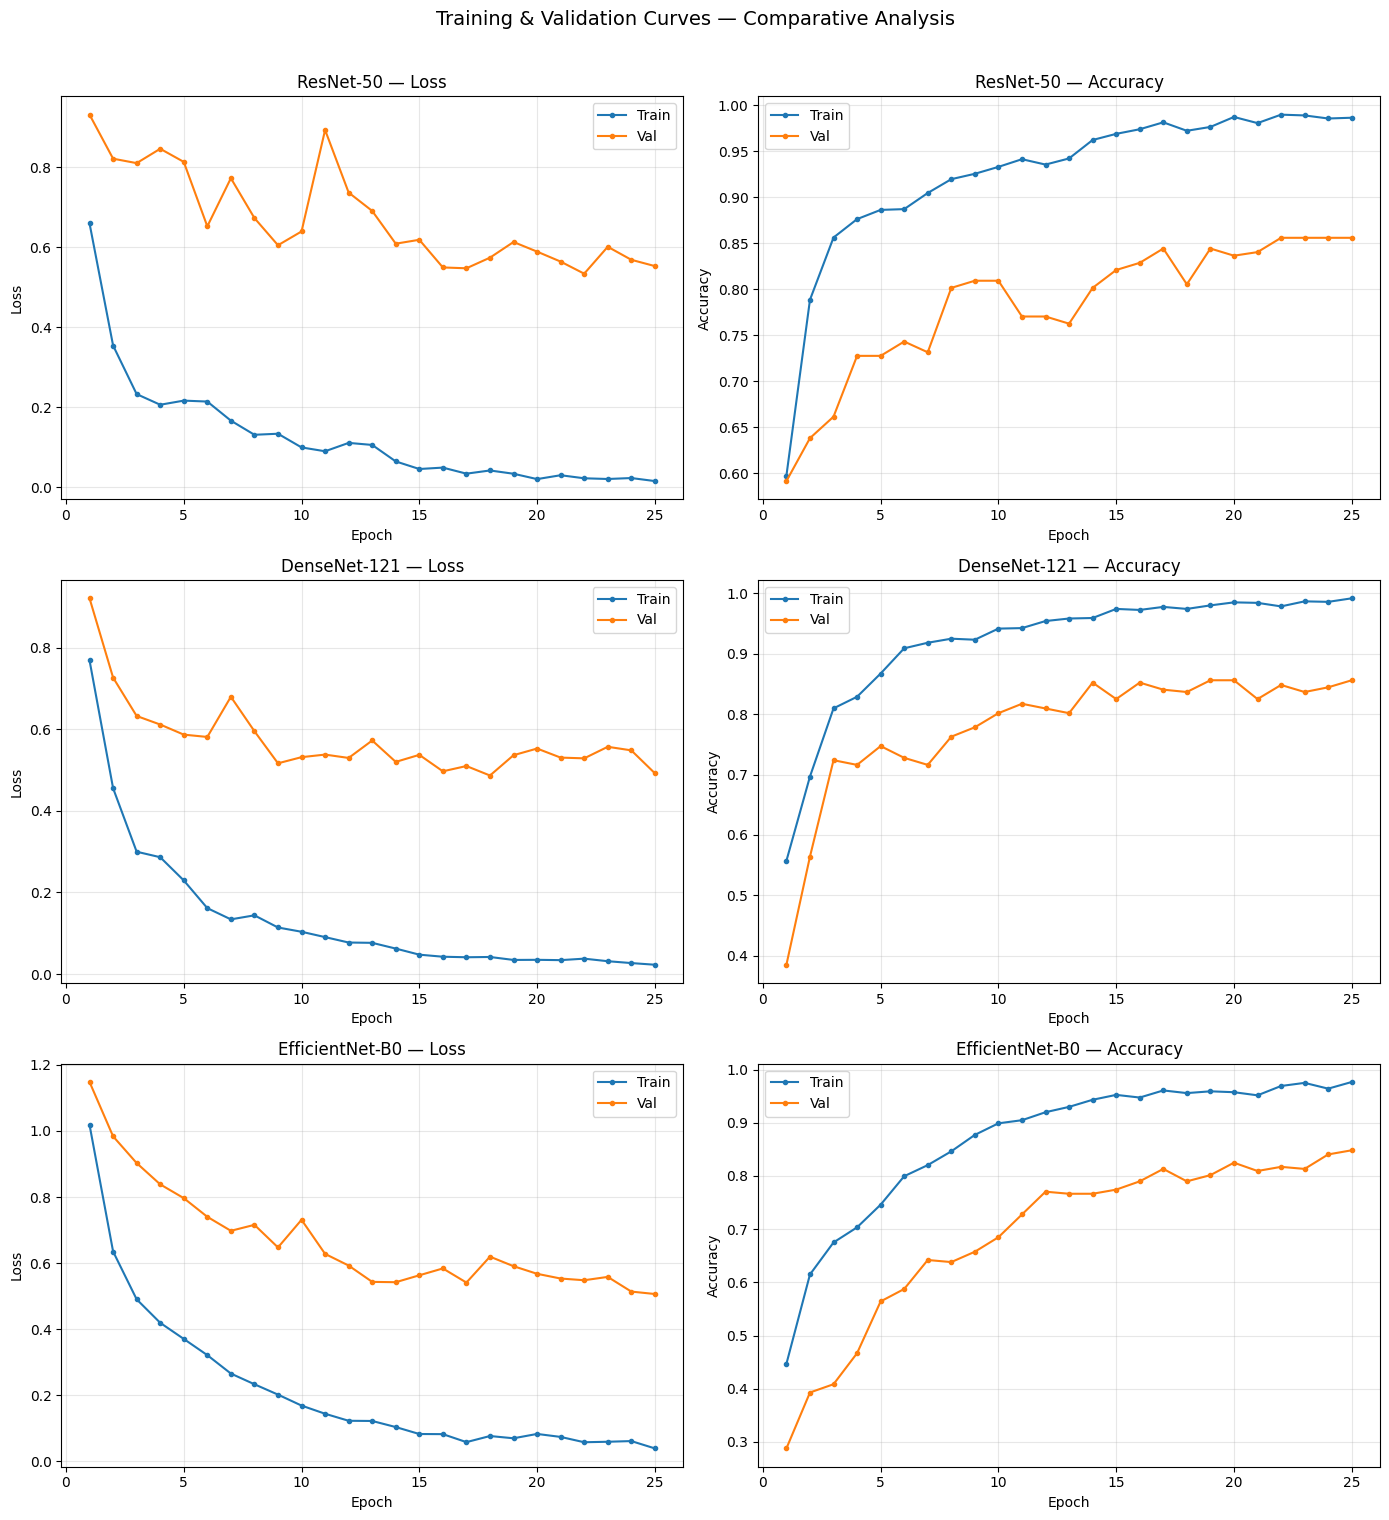

In [13]:
fig, axes = plt.subplots(len(MODEL_REGISTRY), 2, figsize=(14, 5 * len(MODEL_REGISTRY)))

for row, model_name in enumerate(MODEL_REGISTRY.keys()):
    h = histories[model_name]
    epochs = range(1, len(h['train_loss']) + 1)

    axes[row, 0].plot(epochs, h['train_loss'], label='Train', marker='o', markersize=3)
    axes[row, 0].plot(epochs, h['val_loss'],   label='Val',   marker='o', markersize=3)
    axes[row, 0].set_title(f'{model_name} — Loss')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(epochs, h['train_acc'], label='Train', marker='o', markersize=3)
    axes[row, 1].plot(epochs, h['val_acc'],   label='Val',   marker='o', markersize=3)
    axes[row, 1].set_title(f'{model_name} — Accuracy')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)

plt.suptitle('Training & Validation Curves — Comparative Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

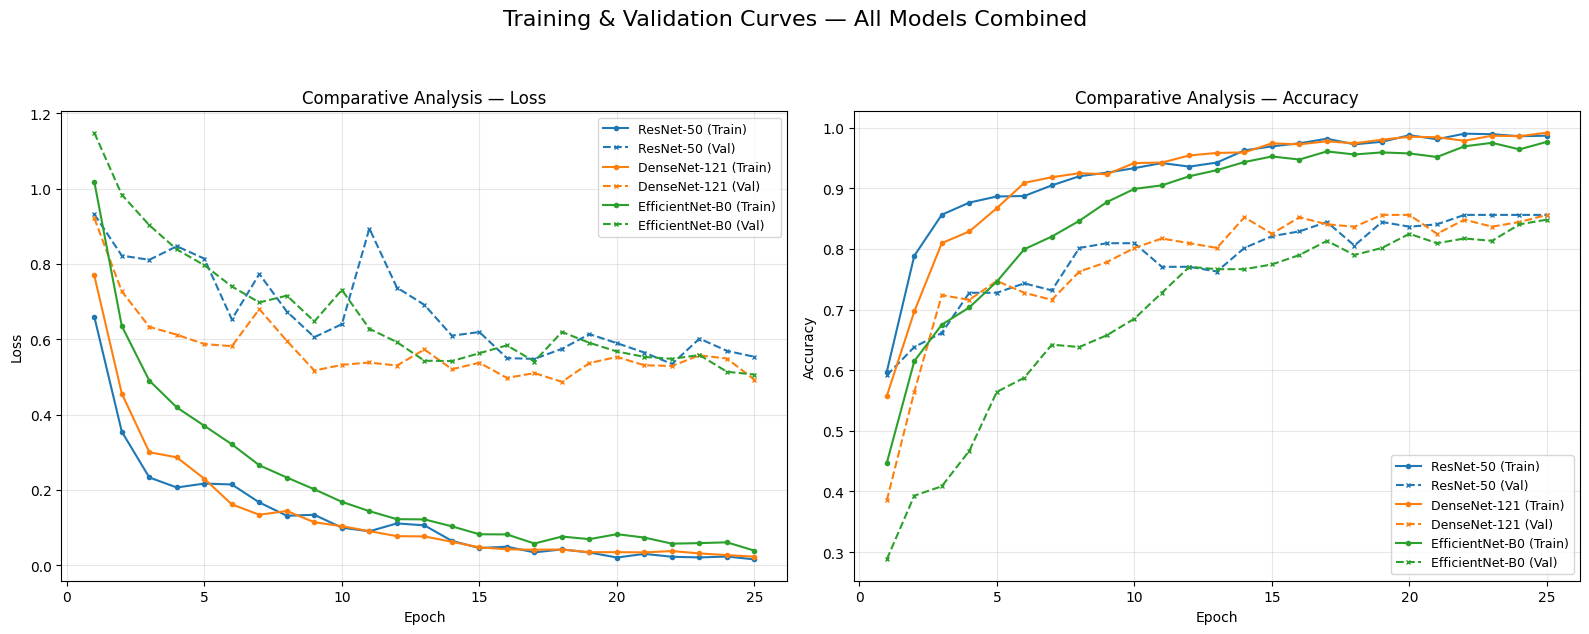

In [14]:
# Buat 1 gambar utama dengan 2 kotak bersebelahan (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Siapkan palet warna agar tiap model punya warna khas
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, model_name in enumerate(MODEL_REGISTRY.keys()):
    h = histories[model_name]
    epochs = range(1, len(h['train_loss']) + 1)

    # Ambil warna sesuai urutan model
    c = colors[i % len(colors)]

    # ==========================
    # KOTAK KIRI: KURVA LOSS
    # ==========================
    axes[0].plot(epochs, h['train_loss'], color=c, linestyle='-', marker='o', markersize=3, label=f'{model_name} (Train)')
    axes[0].plot(epochs, h['val_loss'], color=c, linestyle='--', marker='x', markersize=3, label=f'{model_name} (Val)')

    # ==========================
    # KOTAK KANAN: KURVA ACCURACY
    # ==========================
    axes[1].plot(epochs, h['train_acc'], color=c, linestyle='-', marker='o', markersize=3, label=f'{model_name} (Train)')
    axes[1].plot(epochs, h['val_acc'], color=c, linestyle='--', marker='x', markersize=3, label=f'{model_name} (Val)')

# Format tampilan Kotak Kiri (Loss)
axes[0].set_title('Comparative Analysis — Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Format tampilan Kotak Kanan (Accuracy)
axes[1].set_title('Comparative Analysis — Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Judul Utama & Simpan Gambar
plt.suptitle('Training & Validation Curves — All Models Combined', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. Confusion Matrices

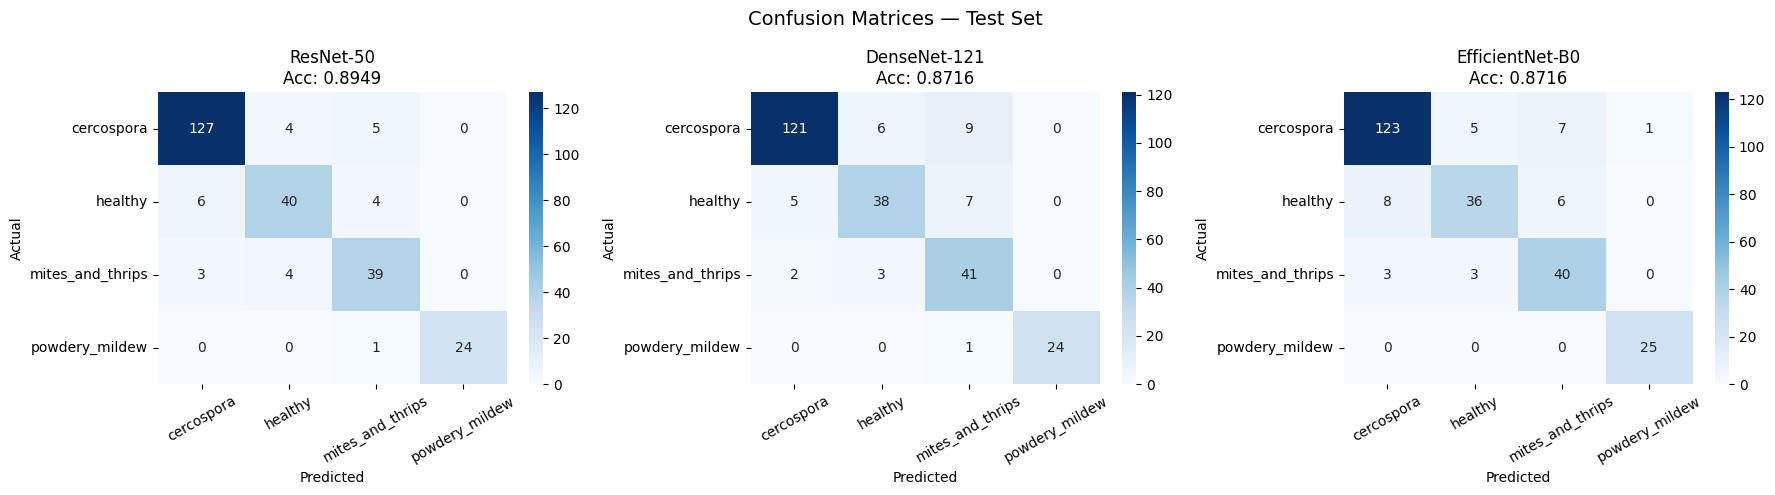

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, MODEL_REGISTRY.keys()):
    r = results[model_name]
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASSES, yticklabels=CLASSES, ax=ax
    )
    ax.set_title(f'{model_name}\nAcc: {r["test_acc"]:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 12. Comparative Metrics Summary

In [16]:
summary_rows = []

for model_name in MODEL_REGISTRY.keys():
    r = results[model_name]
    rpt = r['report']
    row = {
        'Model'        : model_name,
        'Accuracy'     : round(r['test_acc'], 4),
        'Precision_W'  : round(rpt['weighted avg']['precision'], 4),
        'Recall_W'     : round(rpt['weighted avg']['recall'], 4),
        'F1_W'         : round(rpt['weighted avg']['f1-score'], 4),
        'F1_Macro'     : round(rpt['macro avg']['f1-score'], 4),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('\n=== Comparative Metrics ===\n')
print(summary_df.to_string())

summary_df.to_csv('/content/drive/MyDrive/comparative_metrics.csv')
print('\nSaved → comparative_metrics.csv')


=== Comparative Metrics ===

                 Accuracy  Precision_W  Recall_W    F1_W  F1_Macro
Model                                                             
ResNet-50          0.8949       0.8960    0.8949  0.8952    0.8877
DenseNet-121       0.8716       0.8813    0.8716  0.8739    0.8671
EfficientNet-B0    0.8716       0.8735    0.8716  0.8712    0.8664

Saved → comparative_metrics.csv


### 13. Per-Class F1 Score Comparison

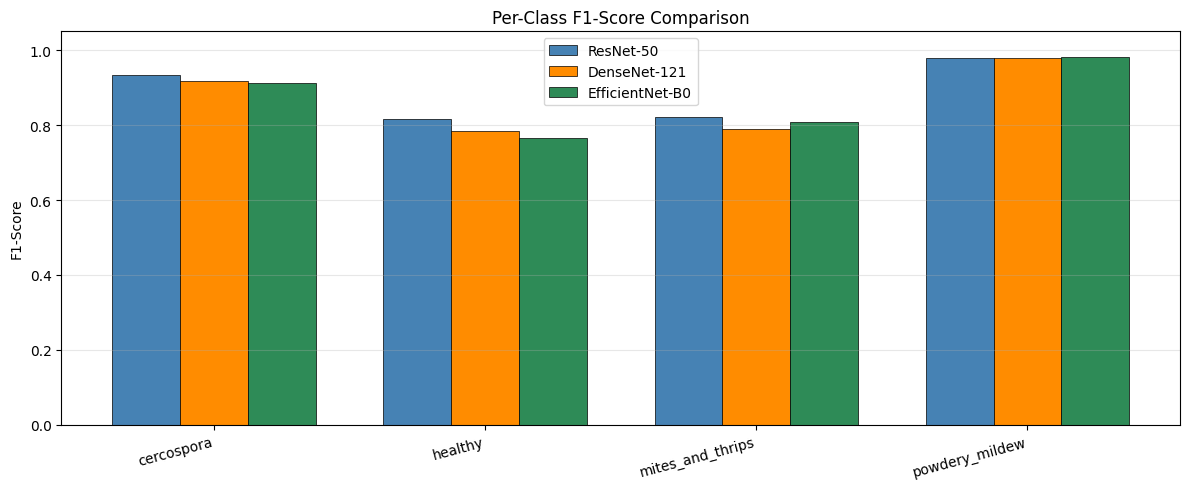

In [17]:
x = np.arange(NUM_CLASSES)
bar_width = 0.25
model_names = list(MODEL_REGISTRY.keys())
colors = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(12, 5))

for i, (mn, color) in enumerate(zip(model_names, colors)):
    f1s = [results[mn]['report'][cls]['f1-score'] for cls in CLASSES]
    ax.bar(x + i * bar_width, f1s, bar_width, label=mn, color=color, edgecolor='black', linewidth=0.5)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(CLASSES, rotation=15, ha='right')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1-Score Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### 14. Full Classification Report per Model

In [18]:
for model_name in MODEL_REGISTRY.keys():
    r = results[model_name]
    print(f'\n{'='*55}')
    print(f'  {model_name}')
    print(f'{'='*55}')
    print(classification_report(r['labels'], r['preds'], target_names=CLASSES))


  ResNet-50
                  precision    recall  f1-score   support

      cercospora       0.93      0.93      0.93       136
         healthy       0.83      0.80      0.82        50
mites_and_thrips       0.80      0.85      0.82        46
  powdery_mildew       1.00      0.96      0.98        25

        accuracy                           0.89       257
       macro avg       0.89      0.89      0.89       257
    weighted avg       0.90      0.89      0.90       257


  DenseNet-121
                  precision    recall  f1-score   support

      cercospora       0.95      0.89      0.92       136
         healthy       0.81      0.76      0.78        50
mites_and_thrips       0.71      0.89      0.79        46
  powdery_mildew       1.00      0.96      0.98        25

        accuracy                           0.87       257
       macro avg       0.87      0.88      0.87       257
    weighted avg       0.88      0.87      0.87       257


  EfficientNet-B0
                  

### 15. Experiment Log

In [19]:
log_rows = []

for model_name in MODEL_REGISTRY.keys():
    r   = results[model_name]
    h   = histories[model_name]
    rpt = r['report']
    log_rows.append({
        'Model'            : model_name,
        'Epochs_Run'       : len(h['train_loss']),
        'LR'               : LR,
        'Batch_Size'       : BATCH_SIZE,
        'Img_Size'         : IMG_SIZE,
        'Test_Accuracy'    : round(r['test_acc'], 4),
        'Precision_W'      : round(rpt['weighted avg']['precision'], 4),
        'Recall_W'         : round(rpt['weighted avg']['recall'], 4),
        'F1_Weighted'      : round(rpt['weighted avg']['f1-score'], 4),
        'F1_Macro'         : round(rpt['macro avg']['f1-score'], 4),
        'Best_Val_Acc'     : round(max(h['val_acc']), 4),
        'Min_Val_Loss'     : round(min(h['val_loss']), 4),
        'Imbalance_Method' : 'WeightedRandomSampler + CrossEntropyLoss(weight)',
        'Augmentation'     : 'HFlip, VFlip, Rotation15, ResizedCrop, ColorJitter(0.05)',
    })

log_df = pd.DataFrame(log_rows)
log_df.to_csv('/content/drive/MyDrive/experiment_log.csv', index=False)
print('Experiment log saved → experiment_log.csv')
log_df

Experiment log saved → experiment_log.csv


,Model,Epochs_Run,LR,Batch_Size,Img_Size,Test_Accuracy,Precision_W,Recall_W,F1_Weighted,F1_Macro,Best_Val_Acc,Min_Val_Loss,Imbalance_Method,Augmentation
0,ResNet-50,25,0.0001,32,224,0.8949,0.8960,0.8949,0.8952,0.8877,0.8560,0.5343,WeightedRandomSampler + CrossEntropyLoss(weight),"HFlip, VFlip, Rotation15, ResizedCrop, ColorJi..."
1,DenseNet-121,25,0.0001,32,224,0.8716,0.8813,0.8716,0.8739,0.8671,0.8560,0.4869,WeightedRandomSampler + CrossEntropyLoss(weight),"HFlip, VFlip, Rotation15, ResizedCrop, ColorJi..."
2,EfficientNet-B0,25,0.0001,32,224,0.8716,0.8735,0.8716,0.8712,0.8664,0.8482,0.5062,WeightedRandomSampler + CrossEntropyLoss(weight),"HFlip, VFlip, Rotation15, ResizedCrop, ColorJi..."


In [21]:
import json
import torch

# --- A. EKSPORT CLASS MAPPING (Versi Custom Dataset) ---
# Kita pakai variabel CLASSES yang udah lu definisikan di awal notebook
# CLASSES = ['cercospora', 'healthy', 'mites_and_thrips', 'powdery_mildew']

idx_to_class = {i: class_name for i, class_name in enumerate(CLASSES)}

mapping_path = '/content/drive/MyDrive/chili_class_mapping.json'
with open(mapping_path, 'w') as f:
    json.dump(idx_to_class, f)

print(f"✅ Mapping label berhasil disimpan ke: {mapping_path}")
print(f"Isi mapping: {idx_to_class}")

# --- B. EKSPORT SEMUA MODEL .PTH (Lanjutin yang tadi) ---
for model_name in MODEL_REGISTRY.keys():
    try:
        # Ambil model dari dictionary results
        model_obj = results[model_name]['model']

        save_name = f"{model_name.replace('-', '_')}_final.pth"
        save_path = f"/content/drive/MyDrive/{save_name}"

        torch.save(model_obj.state_dict(), save_path)
        print(f"✅ Model {model_name} tersimpan.")
    except Exception as e:
        print(f"❌ Gagal simpan {model_name}: {e}")

✅ Mapping label berhasil disimpan ke: /content/drive/MyDrive/chili_class_mapping.json
Isi mapping: {0: 'cercospora', 1: 'healthy', 2: 'mites_and_thrips', 3: 'powdery_mildew'}
✅ Model ResNet-50 tersimpan.
✅ Model DenseNet-121 tersimpan.
✅ Model EfficientNet-B0 tersimpan.
